# Case 2: 2D Buckley–Leverett Waterflood with a PINN

This university-level tutorial develops a two-dimensional waterflood benchmark with an
oblique saturation front. It is the nonlinear follow-up to the smooth groundwater-transport
tutorial and shows both what a PINN can learn and why shocks are difficult.

**Learning objectives:** derive fractional flow from relative permeability, distinguish
characteristics from shocks, construct an entropy solution, train a conservative PINN, and
interpret front-location and mass-balance errors.

## 1. Physical problem and assumptions

Water displaces oil in a homogeneous $300\,\mathrm{m}\times150\,\mathrm{m}$ reservoir over
300 days. With $L_c=150\,\mathrm{m}$ and $T_c=300\,\mathrm{day}$, the dimensionless domain is
$(x,y,t)\in[0,2]\times[0,1]\times[0,1]$. The dimensionless velocity
$(v_x,v_y)=(0.55,0.15)$ represents approximately $(0.275,0.075)\,\mathrm{m/day}$.

We neglect gravity, capillary pressure, compressibility, wells, and heterogeneity. The
oblique planar front depends on both $x$ and $y$, but is deliberately simpler than a
field-scale 2D well-pattern simulation so that an analytical entropy solution is available.

In [1]:
import math
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

X_MAX, Y_MAX, T_MAX = 2.0, 1.0, 1.0
SWC, SOR = 0.20, 0.20
MU_W, MU_O = 1.0, 2.0
VX, VY, INTERFACE_A = 0.55, 0.15, 0.15
VELOCITY_MAGNITUDE = math.hypot(VX, VY)
NX, NY = VX / VELOCITY_MAGNITUDE, VY / VELOCITY_MAGNITUDE

## 2. Effective saturation and fractional flow

Connate-water and residual-oil saturations are $S_{wc}=S_{or}=0.20$. Define effective water
saturation

$$s=\frac{S_w-S_{wc}}{1-S_{wc}-S_{or}},\qquad 0\le s\le1.$$

With the illustrative Corey curves $k_{rw}=s^2$, $k_{ro}=(1-s)^2$ and viscosities
$\mu_w=1$ cP, $\mu_o=2$ cP, water fractional flow is

$$f_w(s)=\frac{k_{rw}/\mu_w}{k_{rw}/\mu_w+k_{ro}/\mu_o}.$$

These parameters are chosen for teaching and are not calibrated reservoir data.

In [2]:
def fractional_flow(s):
    '''Return water fractional flow for effective saturation s.'''
    krw = s.square()
    kro = (1.0 - s).square()
    return (krw / MU_W) / (krw / MU_W + kro / MU_O)

def fractional_flow_derivative(s):
    '''Analytical derivative of the Corey fractional-flow function.'''
    denominator = MU_O*s.square() + MU_W*(1.0-s).square()
    return 2.0*MU_O*MU_W*s*(1.0-s) / denominator.square()

def physical_saturation(effective):
    '''Convert effective saturation to physical water saturation.'''
    return SWC + (1.0 - SWC - SOR) * effective

def shock_properties():
    '''Return shock effective saturation, speed, and tangent mismatch.'''
    sf = 1.0 / math.sqrt(3.0)
    sf_tensor = torch.tensor(sf, dtype=torch.float64)
    sigma = float(fractional_flow(sf_tensor) / sf_tensor)
    mismatch = abs(float(fractional_flow_derivative(sf_tensor)) - sigma)
    return sf, sigma, mismatch

SHOCK_SATURATION, SHOCK_SPEED, SHOCK_MISMATCH = shock_properties()

def effective_saturation_exact(xyt):
    '''Evaluate the oblique planar Buckley–Leverett entropy solution.'''
    if xyt.ndim != 2 or xyt.shape[1] != 3:
        raise ValueError("xyt must have shape (N, 3)")
    x, y, t = xyt[:, 0:1], xyt[:, 1:2], xyt[:, 2:3]
    normal_position = NX*x + NY*y
    initial = (normal_position <= INTERFACE_A).to(xyt.dtype)

    positive_time = t > 0.0
    safe_t = torch.where(positive_time, t, torch.ones_like(t))
    eta = (normal_position - INTERFACE_A) / (VELOCITY_MAGNITUDE*safe_t)

    lo = torch.full_like(eta, SHOCK_SATURATION)
    hi = torch.ones_like(eta)
    for _ in range(64):
        mid = 0.5 * (lo + hi)
        derivative = fractional_flow_derivative(mid)
        lo = torch.where(derivative > eta, mid, lo)
        hi = torch.where(derivative > eta, hi, mid)
    rarefaction = 0.5 * (lo + hi)
    evolved = torch.where(
        eta <= 0.0,
        torch.ones_like(eta),
        torch.where(eta < SHOCK_SPEED, rarefaction, torch.zeros_like(eta)),
    )
    return torch.where(positive_time, evolved, initial)

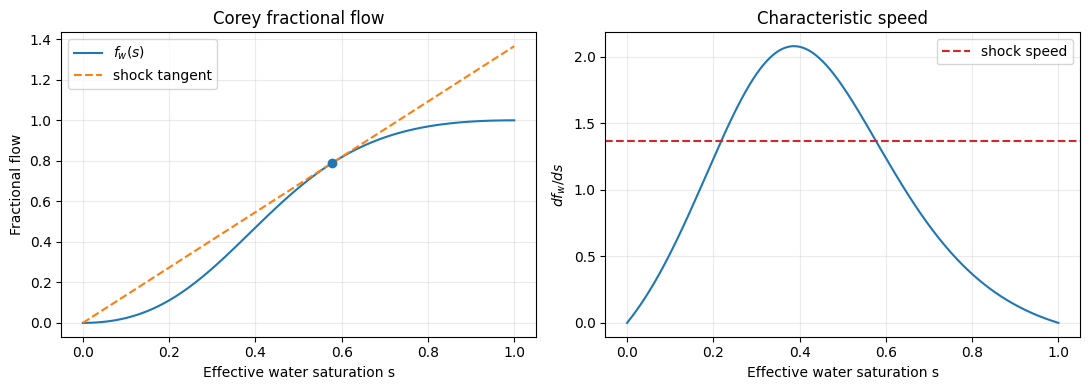

In [3]:
saturation_axis = torch.linspace(0.0, 1.0, 501, dtype=torch.float64)
flow_axis = fractional_flow(saturation_axis)
derivative_axis = fractional_flow_derivative(saturation_axis)
tangent_axis = SHOCK_SPEED*saturation_axis

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(saturation_axis, flow_axis, label=r"$f_w(s)$")
axes[0].plot(saturation_axis, tangent_axis, "--", label="shock tangent")
axes[0].scatter([SHOCK_SATURATION], [fractional_flow(torch.tensor(SHOCK_SATURATION))], zorder=3)
axes[0].set(xlabel="Effective water saturation s", ylabel="Fractional flow",
            title="Corey fractional flow")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(saturation_axis, derivative_axis)
axes[1].axhline(SHOCK_SPEED, linestyle="--", color="tab:red", label="shock speed")
axes[1].set(xlabel="Effective water saturation s", ylabel=r"$df_w/ds$",
            title="Characteristic speed")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Conservation law, characteristics, and shock formation

Water conservation gives the dimensionless nonlinear hyperbolic equation

$$s_t+v_x[f_w(s)]_x+v_y[f_w(s)]_y=0.$$

In a smooth region, a constant saturation travels at a speed proportional to $f_w'(s)$.
Because different saturations travel at different speeds, characteristics intersect and a
classical single-valued solution ceases to exist. Conservation then selects a moving shock.

The initial interface is the oblique line $r=a$, where
$r=n_xx+n_yy$, $\mathbf{n}=\mathbf{v}/|\mathbf{v}|$, and $a=0.15$. Initially $s=1$ on the
upstream side and $s=0$ downstream.

In [4]:
print(f"Shock effective saturation: {SHOCK_SATURATION:.8f}")
print(f"Shock physical water saturation: {float(physical_saturation(torch.tensor(SHOCK_SATURATION))):.8f}")
print(f"Dimensionless shock speed: {SHOCK_SPEED:.8f}")
print(f"Rankine-Hugoniot tangent mismatch: {SHOCK_MISMATCH:.3e}")

Shock effective saturation: 0.57735027
Shock physical water saturation: 0.54641014
Dimensionless shock speed: 1.36602540
Rankine-Hugoniot tangent mismatch: 4.441e-16


## 4. Analytical entropy solution

For $t>0$, introduce the self-similar coordinate

$$\eta=\frac{r-a}{|\mathbf{v}|t}.$$

The shock state $s_f$ is determined by the Rankine–Hugoniot tangent condition

$$f_w'(s_f)=\frac{f_w(s_f)-f_w(0)}{s_f-0}.$$

Here $s_f=1/\sqrt{3}$ and the shock speed is $\sigma=1.3660254$. The entropy solution has
$s=1$ for $\eta\le0$, a rarefaction satisfying $f_w'(s)=\eta$ for
$0<\eta<\sigma$, and $s=0$ beyond the shock. The bisection evaluator below is used only for
initial/boundary targets and held-out validation—never as an interior label.

In [5]:
def exact_smooth_residual_check(step=1e-5):
    '''Finite-difference PDE check at rarefaction states away from junctions.'''
    s = torch.linspace(SHOCK_SATURATION + 0.03, 0.95, 12, dtype=torch.float64)
    t = torch.full_like(s, 0.50)
    y = torch.full_like(s, 0.40)
    eta = fractional_flow_derivative(s)
    normal_position = INTERFACE_A + VELOCITY_MAGNITUDE*t*eta
    x = (normal_position - NY*y)/NX
    points = torch.stack([x, y, t], dim=1)
    def shifted(axis, amount):
        moved = points.clone()
        moved[:, axis] += amount
        return effective_saturation_exact(moved)[:, 0]
    s_t = (shifted(2, step)-shifted(2, -step))/(2.0*step)
    fw_x = (fractional_flow(shifted(0, step))-fractional_flow(shifted(0, -step)))/(2.0*step)
    fw_y = (fractional_flow(shifted(1, step))-fractional_flow(shifted(1, -step)))/(2.0*step)
    return s_t + VX*fw_x + VY*fw_y

analytical_residual = exact_smooth_residual_check()
print(f"Maximum smooth-region analytical PDE residual: {analytical_residual.abs().max().item():.3e}")

Maximum smooth-region analytical PDE residual: 1.687e-09


## 5. GPU preference and CPU fallback

A free Colab GPU is not guaranteed. The code performs an actual CUDA tensor calculation
before selecting the GPU. If it fails, the reason is printed and execution immediately
falls back to the CPU.

In [6]:
def select_device():
    '''Prefer CUDA only after a real allocation and arithmetic probe.'''
    if torch.cuda.is_available():
        try:
            probe = torch.empty(1, device="cuda")
            probe.fill_(2.0).square().sum().item()
            torch.cuda.synchronize()
            print(f"Using GPU: {torch.cuda.get_device_name(0)}")
            return torch.device("cuda")
        except Exception as error:
            try:
                torch.cuda.empty_cache()
            except Exception:
                pass
            print(f"CUDA initialization failed ({error}); switching to CPU.")
    else:
        print("No usable GPU is available in this runtime; using CPU.")
    return torch.device("cpu")

device = select_device()

Using GPU: Tesla T4


## 6. Sampling training points

Four sets support training: uniform interior collocation points, additional unlabeled points
near the moving shock plane, initial-condition points, and points on all four spatial edges.
Front-aware sampling tells the residual where resolution is difficult without revealing the
analytical saturation there. A narrow central gap avoids applying a classical pointwise
residual exactly where the ideal entropy solution is discontinuous.

In [7]:
def front_coordinate(xyt):
    '''Signed normal distance from the analytical shock plane.'''
    normal_position = NX*xyt[:, 0:1] + NY*xyt[:, 1:2]
    return (
        normal_position - INTERFACE_A
        - VELOCITY_MAGNITUDE*SHOCK_SPEED*xyt[:, 2:3]
    )

def sample_points(config, device):
    '''Sample uniform PDE, front-band, initial, and boundary point sets.'''
    counts = {
        name: int(config[name])
        for name in ("n_pde", "n_front", "n_ic", "n_bc_each")
    }
    if any(value <= 0 for value in counts.values()):
        raise ValueError("All sample counts must be positive integers.")
    band = float(config["front_band"])
    if not math.isfinite(band) or band <= 0.0:
        raise ValueError("front_band must be positive and finite.")

    def uniform_domain(number):
        values = torch.rand(number, 3, device=device)
        values[:, 0] *= X_MAX
        values[:, 1] *= Y_MAX
        values[:, 2] *= T_MAX
        return values

    pde = uniform_domain(counts["n_pde"])

    accepted = []
    remaining = counts["n_front"]
    for _ in range(100):
        candidates = uniform_domain(max(1024, 32*remaining))
        distance = front_coordinate(candidates).abs()[:, 0]
        inside_band = (distance <= band) & (distance >= 0.5*band)
        chosen = candidates[inside_band][:remaining]
        if len(chosen):
            accepted.append(chosen)
            remaining -= len(chosen)
        if remaining == 0:
            break
    if remaining:
        raise RuntimeError("Could not sample enough points in the shock-front band.")
    front = torch.cat(accepted, dim=0)

    ic = uniform_domain(counts["n_ic"])
    ic[:, 2] = 0.0

    def edge_points(axis, value):
        edge = uniform_domain(counts["n_bc_each"])
        edge[:, axis] = value
        return edge

    bc = torch.cat([
        edge_points(0, 0.0), edge_points(0, X_MAX),
        edge_points(1, 0.0), edge_points(1, Y_MAX),
    ], dim=0)
    points = {"pde": pde, "front": front, "ic": ic, "bc": bc}

    for name, tensor in points.items():
        if tensor.ndim != 2 or tensor.shape[1] != 3:
            raise AssertionError(f"{name} must have shape (N, 3)")
        if not torch.isfinite(tensor).all():
            raise AssertionError(f"{name} contains non-finite values")
        inside = (
            (tensor[:, 0] >= 0.0) & (tensor[:, 0] <= X_MAX)
            & (tensor[:, 1] >= 0.0) & (tensor[:, 1] <= Y_MAX)
            & (tensor[:, 2] >= 0.0) & (tensor[:, 2] <= T_MAX)
        )
        if not inside.all():
            raise AssertionError(f"{name} contains out-of-domain points")
    return points

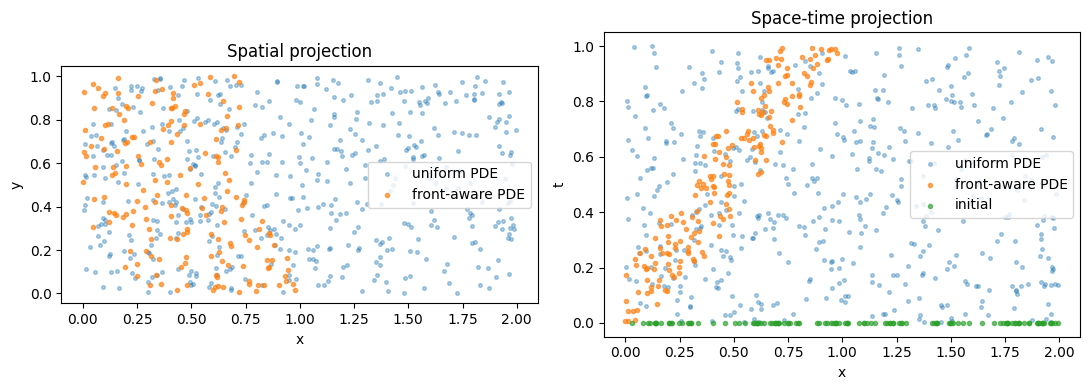

In [8]:
preview_config = dict(n_pde=500, n_front=180, n_ic=120, n_bc_each=50, front_band=0.04)
preview = sample_points(preview_config, torch.device("cpu"))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(preview["pde"][:, 0], preview["pde"][:, 1], s=7, alpha=0.35,
                label="uniform PDE")
axes[0].scatter(preview["front"][:, 0], preview["front"][:, 1], s=9, alpha=0.65,
                label="front-aware PDE")
axes[0].set(xlabel="x", ylabel="y", title="Spatial projection")
axes[0].set_aspect("equal")
axes[0].legend()
axes[1].scatter(preview["pde"][:, 0], preview["pde"][:, 2], s=7, alpha=0.35,
                label="uniform PDE")
axes[1].scatter(preview["front"][:, 0], preview["front"][:, 2], s=9, alpha=0.65,
                label="front-aware PDE")
axes[1].scatter(preview["ic"][:, 0], preview["ic"][:, 2], s=9, alpha=0.65,
                label="initial")
axes[1].set(xlabel="x", ylabel="t", title="Space-time projection")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. PINN architecture and conservative residual

The network maps $(x,y,t)$ to effective saturation. Inputs are scaled to $[-1,1]^3$, four
hidden layers use 64 `tanh` neurons each, and a sigmoid output enforces $0\le s\le1$. Thus
physical water saturation is always between 0.20 and 0.80.

Automatic differentiation evaluates the conservative residual

$$r_f=s_t+v_x[f_w(s)]_x+v_y[f_w(s)]_y.$$

In [9]:
def normalize_inputs(xyt):
    '''Map the rectangular space-time domain to [-1, 1]^3.'''
    lower = xyt.new_tensor([0.0, 0.0, 0.0])
    upper = xyt.new_tensor([X_MAX, Y_MAX, T_MAX])
    return 2.0*(xyt - lower)/(upper - lower) - 1.0

class PINN(nn.Module):
    def __init__(self, hidden_width=64, hidden_layers=4):
        super().__init__()
        if hidden_width <= 0 or hidden_layers <= 0:
            raise ValueError("hidden_width and hidden_layers must be positive")
        layers = []
        in_features = 3
        for _ in range(hidden_layers):
            layer = nn.Linear(in_features, hidden_width)
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)
            layers.extend([layer, nn.Tanh()])
            in_features = hidden_width
        output = nn.Linear(in_features, 1)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.network = nn.Sequential(*layers)

    def forward(self, xyt):
        return torch.sigmoid(self.network(normalize_inputs(xyt)))

def pde_residual(model, xyt):
    '''Return the conservative Buckley–Leverett residual.'''
    xyt_grad = xyt.detach().clone().requires_grad_(True)
    saturation = model(xyt_grad)
    flux = fractional_flow(saturation)
    grad_s = torch.autograd.grad(
        saturation, xyt_grad, torch.ones_like(saturation), create_graph=True
    )[0]
    grad_flux = torch.autograd.grad(
        flux, xyt_grad, torch.ones_like(flux), create_graph=True
    )[0]
    return grad_s[:, 2:3] + VX*grad_flux[:, 0:1] + VY*grad_flux[:, 1:2]

def shock_kinematic_residual(model, xyt):
    '''Enforce the Rankine-Hugoniot shock speed without saturation labels.'''
    xyt_grad = xyt.detach().clone().requires_grad_(True)
    saturation = model(xyt_grad)
    grad_s = torch.autograd.grad(
        saturation, xyt_grad, torch.ones_like(saturation), create_graph=True
    )[0]
    normal_derivative = NX*grad_s[:, 0:1] + NY*grad_s[:, 1:2]
    return (
        grad_s[:, 2:3]
        + VELOCITY_MAGNITUDE*SHOCK_SPEED*normal_derivative
    )

## 8. Model training

In addition to the pointwise conservation residual, the loss includes initial and boundary
data, a global integral balance, and a weak monotonicity preference along the flow direction:

$$\mathcal{L}=w_fL_f+w_iL_i+w_bL_b+w_mL_m+w_{mono}L_{mono}+w_{RH}L_{RH}.$$

The mass term approximates the domain-integrated conservation law using midpoint quadrature;
it is a training aid, not a replacement for a finite-volume discretization. At front-aware
points, the Rankine–Hugoniot kinematic term enforces the derived shock speed without supplying
saturation labels. Fresh points are sampled at every Adam step, so individual loss values
fluctuate.

In [10]:
def mass_balance_residual(model, device, time_value=None, nx=8, ny=4):
    '''Approximate d/dt integral(s) plus outward boundary flux at one time.'''
    if nx <= 0 or ny <= 0:
        raise ValueError("Quadrature dimensions must be positive")
    if time_value is None:
        time_value = float(torch.rand((), device=device))

    x = (torch.arange(nx, device=device, dtype=torch.float32) + 0.5) * X_MAX/nx
    y = (torch.arange(ny, device=device, dtype=torch.float32) + 0.5) * Y_MAX/ny
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    tt = torch.full_like(xx, float(time_value))
    interior = torch.stack([xx.reshape(-1), yy.reshape(-1), tt.reshape(-1)], dim=1)
    interior.requires_grad_(True)
    saturation = model(interior)
    grad_s = torch.autograd.grad(
        saturation, interior, torch.ones_like(saturation), create_graph=True
    )[0]
    mass_rate = X_MAX*Y_MAX*grad_s[:, 2:3].mean()

    y_edge = (torch.arange(ny, device=device, dtype=torch.float32) + 0.5)*Y_MAX/ny
    x_edge = (torch.arange(nx, device=device, dtype=torch.float32) + 0.5)*X_MAX/nx
    t_y = torch.full_like(y_edge, float(time_value))
    t_x = torch.full_like(x_edge, float(time_value))
    left = torch.stack([torch.zeros_like(y_edge), y_edge, t_y], dim=1)
    right = torch.stack([torch.full_like(y_edge, X_MAX), y_edge, t_y], dim=1)
    bottom = torch.stack([x_edge, torch.zeros_like(x_edge), t_x], dim=1)
    top = torch.stack([x_edge, torch.full_like(x_edge, Y_MAX), t_x], dim=1)
    outward_flux = (
        VX*Y_MAX*(fractional_flow(model(right)).mean() - fractional_flow(model(left)).mean())
        + VY*X_MAX*(fractional_flow(model(top)).mean() - fractional_flow(model(bottom)).mean())
    )
    return mass_rate + outward_flux

def compute_losses(model, points, config):
    '''Compute all named training losses and their weighted sum.'''
    weights = config.get("weights", {})
    required = {"pde", "ic", "bc", "mass", "mono", "rh"}
    if set(weights) != required:
        raise ValueError(f"weights must contain exactly {sorted(required)}")

    collocation = points["pde"]
    residual = pde_residual(model, collocation)
    loss_pde = residual.square().mean()
    loss_rh = shock_kinematic_residual(model, points["front"]).square().mean()
    loss_ic = (model(points["ic"]) - effective_saturation_exact(points["ic"])).square().mean()
    loss_bc = (model(points["bc"]) - effective_saturation_exact(points["bc"])).square().mean()

    monotonic_points = collocation.detach().clone().requires_grad_(True)
    monotonic_saturation = model(monotonic_points)
    monotonic_gradient = torch.autograd.grad(
        monotonic_saturation, monotonic_points,
        torch.ones_like(monotonic_saturation), create_graph=True,
    )[0]
    normal_derivative = NX*monotonic_gradient[:, 0:1] + NY*monotonic_gradient[:, 1:2]
    loss_mono = torch.relu(normal_derivative).square().mean()
    balance = mass_balance_residual(model, collocation.device)
    loss_mass = balance.square()
    components = {
        "pde": loss_pde,
        "ic": loss_ic,
        "bc": loss_bc,
        "mass": loss_mass,
        "mono": loss_mono,
        "rh": loss_rh,
    }
    total = sum(float(weights[name])*value for name, value in components.items())
    return {"total": total, **components}

def train_model(model, config, device):
    '''Train with fresh collocation points at every Adam iteration.'''
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=float(config["learning_rate"]))
    names = ("total", "pde", "ic", "bc", "mass", "mono", "rh")
    history = {name: [] for name in names}
    started = time.perf_counter()
    for step in range(1, int(config["iterations"]) + 1):
        points = sample_points(config, device)
        losses = compute_losses(model, points, config)
        if not all(torch.isfinite(value).item() for value in losses.values()):
            raise FloatingPointError(f"Non-finite loss at iteration {step}")
        optimizer.zero_grad(set_to_none=True)
        losses["total"].backward()
        optimizer.step()
        for name in names:
            history[name].append(float(losses[name].detach().cpu()))
        if step == 1 or step % int(config["print_every"]) == 0:
            elapsed = time.perf_counter() - started
            print(
                f"iteration {step:5d}/{config['iterations']} | "
                f"total={history['total'][-1]:.3e} | "
                f"PDE={history['pde'][-1]:.3e} | "
                f"IC={history['ic'][-1]:.3e} | "
                f"BC={history['bc'][-1]:.3e} | "
                f"mass={history['mass'][-1]:.3e} | "
                f"mono={history['mono'][-1]:.3e} | "
                f"RH={history['rh'][-1]:.3e} | {elapsed:.1f} s"
            )
    return history

In [11]:
def relative_l2_error(prediction, truth):
    '''Return ||prediction-truth||_2 / ||truth||_2.'''
    prediction = torch.as_tensor(prediction)
    truth = torch.as_tensor(truth, device=prediction.device)
    denominator = torch.linalg.vector_norm(truth)
    if denominator.item() == 0.0:
        raise ValueError("truth must have a non-zero L2 norm")
    return float((torch.linalg.vector_norm(prediction-truth)/denominator).detach().cpu())

def mean_absolute_error(prediction, truth):
    '''Return the mean absolute error.'''
    prediction = torch.as_tensor(prediction)
    truth = torch.as_tensor(truth, device=prediction.device)
    return float(torch.mean(torch.abs(prediction-truth)).detach().cpu())

def steepest_front_curve(xx, yy, prediction):
    '''Return a sub-grid front curve from row-wise steepest descent.'''
    xx = torch.as_tensor(xx)
    yy = torch.as_tensor(yy)
    prediction = torch.as_tensor(prediction)
    if prediction.shape != xx.shape or yy.shape != xx.shape:
        raise ValueError("xx, yy, and prediction must have identical shapes")
    if prediction.shape[1] < 4:
        raise ValueError("front detection requires at least four x points")
    slope = (prediction[:, 1:]-prediction[:, :-1])/(xx[:, 1:]-xx[:, :-1])
    centers = 0.5*(xx[:, 1:]+xx[:, :-1])
    rows = torch.arange(prediction.shape[0], device=prediction.device)
    indices = torch.argmin(slope, dim=1).clamp(1, slope.shape[1]-2)
    left = slope[rows, indices-1]
    middle = slope[rows, indices]
    right = slope[rows, indices+1]
    denominator = left - 2.0*middle + right
    offset = torch.where(
        denominator.abs() > 1e-12,
        0.5*(left-right)/denominator,
        torch.zeros_like(denominator),
    ).clamp(-1.0, 1.0)
    dx = centers[:, 1]-centers[:, 0]
    front_x = centers[rows, indices] + offset*dx
    front_y = yy[:, 0]
    return front_x, front_y

def front_position_error(xx, yy, prediction, time_value):
    '''Estimate shock-plane error from row-wise steepest-descent locations.'''
    front_x, front_y = steepest_front_curve(xx, yy, prediction)
    predicted_normal = NX*front_x + NY*front_y
    predicted_front = torch.median(predicted_normal)
    exact_front = INTERFACE_A + VELOCITY_MAGNITUDE*SHOCK_SPEED*float(time_value)
    return float(torch.abs(predicted_front-exact_front))

In [12]:
FAST_MODE = True
FAST_CONFIG = dict(
    n_pde=1200, n_front=400, n_ic=300, n_bc_each=100,
    front_band=0.04, iterations=3000, learning_rate=1e-3,
    print_every=300,
    weights={"pde":1.0, "ic":10.0, "bc":10.0, "mass":1.0, "mono":0.1, "rh":1.0},
)
ACCURATE_CONFIG = dict(
    n_pde=5000, n_front=1500, n_ic=1000, n_bc_each=400,
    front_band=0.025, iterations=10000, learning_rate=1e-3,
    print_every=500,
    weights={"pde":1.0, "ic":10.0, "bc":10.0, "mass":1.0, "mono":0.1, "rh":1.0},
)

Mode: FAST_MODE (classroom demonstration)
Device: cuda; configuration: {'n_pde': 1200, 'n_front': 400, 'n_ic': 300, 'n_bc_each': 100, 'front_band': 0.04, 'iterations': 3000, 'learning_rate': 0.001, 'print_every': 300, 'weights': {'pde': 1.0, 'ic': 10.0, 'bc': 10.0, 'mass': 1.0, 'mono': 0.1, 'rh': 1.0}}
iteration     1/3000 | total=4.373e+00 | PDE=2.002e-04 | IC=2.294e-01 | BC=2.078e-01 | mass=7.777e-04 | mono=0.000e+00 | RH=4.622e-04 | 0.9 s
iteration   300/3000 | total=2.454e-01 | PDE=7.793e-02 | IC=9.164e-03 | BC=6.139e-03 | mass=7.368e-03 | mono=0.000e+00 | RH=7.081e-03 | 18.0 s
iteration   600/3000 | total=1.940e-01 | PDE=9.215e-02 | IC=3.483e-03 | BC=5.061e-03 | mass=7.138e-03 | mono=0.000e+00 | RH=9.242e-03 | 35.5 s
iteration   900/3000 | total=1.977e-01 | PDE=7.383e-02 | IC=7.067e-03 | BC=3.602e-03 | mass=7.310e-03 | mono=0.000e+00 | RH=9.842e-03 | 52.1 s
iteration  1200/3000 | total=1.577e-01 | PDE=6.598e-02 | IC=3.340e-03 | BC=4.850e-03 | mass=4.837e-04 | mono=0.000e+00 | RH=9

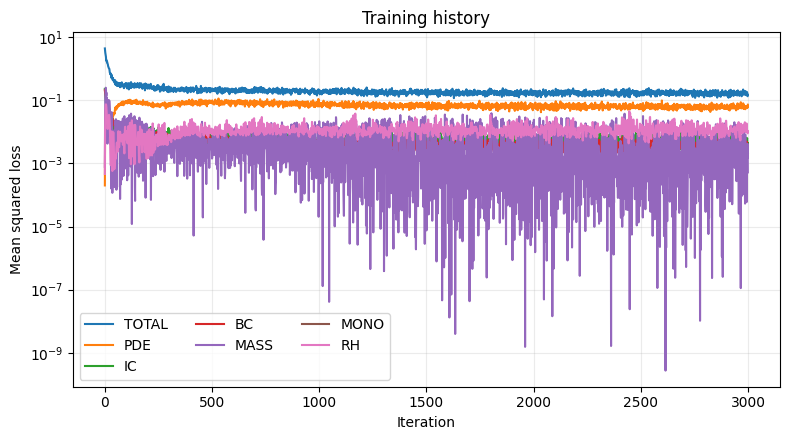

In [13]:
config = FAST_CONFIG.copy() if FAST_MODE else ACCURATE_CONFIG.copy()
mode_name = "FAST_MODE (classroom demonstration)" if FAST_MODE else "ACCURATE_MODE (higher accuracy)"
print(f"Mode: {mode_name}")
print(f"Device: {device}; configuration: {config}")

model = PINN(hidden_width=64, hidden_layers=4)
training_started = time.perf_counter()
history = train_model(model, config, device)
training_seconds = time.perf_counter() - training_started
print(f"Training completed in {training_seconds:.1f} s")

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, values in history.items():
    ax.semilogy(values, label=name.upper())
ax.set(xlabel="Iteration", ylabel="Mean squared loss", title="Training history")
ax.grid(True, which="both", alpha=0.25)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## 9. Results and error analysis

We evaluate on structured grids that were not used for training. At three times, compare the
analytical and PINN physical water saturations, absolute error, front location, and total
water content. Because a continuous PINN smears a discontinuity, its numerical front is
defined by the steepest saturation descent rather than by the left shock-state contour. The
front error is a normal-distance error; 0.05 corresponds to 7.5 m under the chosen scale.

In [14]:
def evaluate_grid(model, time_value, device, nx=161, ny=81):
    '''Evaluate the model and entropy solution on a held-out grid.'''
    x = torch.linspace(0.0, X_MAX, nx)
    y = torch.linspace(0.0, Y_MAX, ny)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    tt = torch.full_like(xx, float(time_value))
    xyt_cpu = torch.stack([xx.reshape(-1), yy.reshape(-1), tt.reshape(-1)], dim=1)
    predictions = []
    model.eval()
    with torch.no_grad():
        for chunk in xyt_cpu.split(4096):
            predictions.append(model(chunk.to(device)).cpu())
        prediction = torch.cat(predictions, dim=0).reshape(ny, nx)
        truth = effective_saturation_exact(xyt_cpu).reshape(ny, nx)
    return xx, yy, truth, prediction

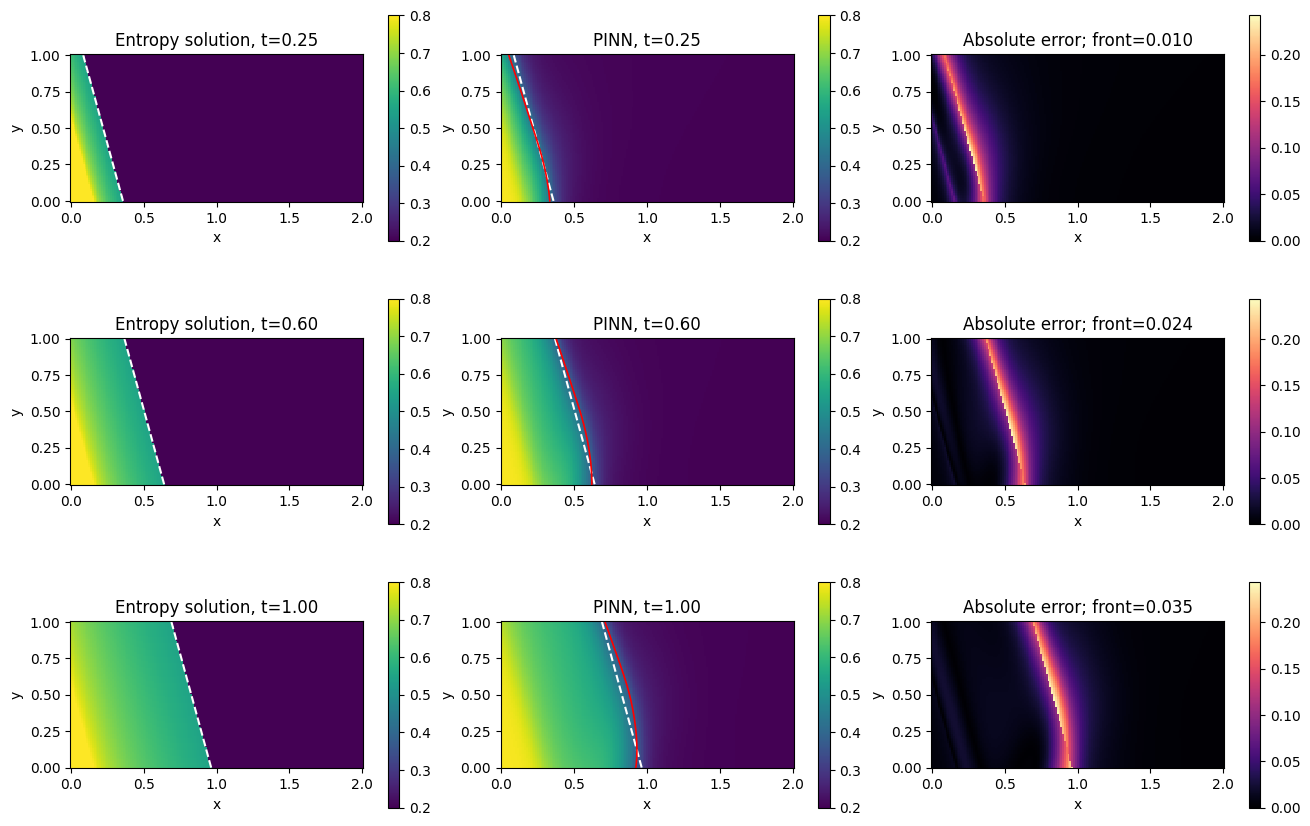


Held-out grid metrics (analytical interior values are evaluation-only):
 time    rel_L2       MAE       front_err  mass_err    pred_min  pred_max
 0.25  1.2831e-01 1.7615e-02 9.8664e-03 8.3872e-03    0.2014    0.7955
 0.60  1.0888e-01 1.9557e-02 2.3546e-02 7.7493e-03    0.2012    0.7955
 1.00  9.5413e-02 2.1537e-02 3.5310e-02 6.5652e-03    0.2013    0.7950
Maximum front-position error: 0.035310


In [15]:
EVALUATION_TIMES = [0.25, 0.60, 1.00]
fig, axes = plt.subplots(
    len(EVALUATION_TIMES), 3, figsize=(13, 8.5), constrained_layout=True
)
metric_rows = []

for row, time_value in enumerate(EVALUATION_TIMES):
    xx, yy, truth_effective, prediction_effective = evaluate_grid(model, time_value, device)
    truth = physical_saturation(truth_effective)
    prediction = physical_saturation(prediction_effective)
    absolute_error = torch.abs(prediction-truth)
    l2_error = relative_l2_error(prediction, truth)
    mae = mean_absolute_error(prediction, truth)
    front_error = front_position_error(xx, yy, prediction_effective, time_value)
    predicted_front_x, predicted_front_y = steepest_front_curve(
        xx, yy, prediction_effective
    )
    exact_normal = INTERFACE_A + VELOCITY_MAGNITUDE*SHOCK_SPEED*time_value
    exact_front_y = yy[:, 0]
    exact_front_x = (exact_normal-NY*exact_front_y)/NX
    mass_error = float(torch.abs(prediction.mean()-truth.mean()))
    metric_rows.append((time_value, l2_error, mae, front_error, mass_error,
                        float(prediction.min()), float(prediction.max())))

    exact_plot = axes[row, 0].pcolormesh(
        xx, yy, truth, shading="auto", vmin=SWC, vmax=1.0-SOR, cmap="viridis"
    )
    pred_plot = axes[row, 1].pcolormesh(
        xx, yy, prediction, shading="auto", vmin=SWC, vmax=1.0-SOR, cmap="viridis"
    )
    error_plot = axes[row, 2].pcolormesh(
        xx, yy, absolute_error, shading="auto", vmin=0.0, cmap="magma"
    )
    axes[row, 0].plot(exact_front_x, exact_front_y, "w--", linewidth=1.5)
    axes[row, 1].plot(exact_front_x, exact_front_y, "w--", linewidth=1.5,
                      label="exact front")
    axes[row, 1].plot(predicted_front_x, predicted_front_y, color="red", linewidth=1.2,
                      label="PINN steepest front")
    axes[row, 0].set_title(f"Entropy solution, t={time_value:.2f}")
    axes[row, 1].set_title(f"PINN, t={time_value:.2f}")
    axes[row, 2].set_title(f"Absolute error; front={front_error:.3f}")
    fig.colorbar(exact_plot, ax=axes[row, 0], shrink=0.82)
    fig.colorbar(pred_plot, ax=axes[row, 1], shrink=0.82)
    fig.colorbar(error_plot, ax=axes[row, 2], shrink=0.82)
    for ax in axes[row]:
        ax.set(xlabel="x", ylabel="y")
        ax.set_aspect("equal")

plt.show()
print()
print("Held-out grid metrics (analytical interior values are evaluation-only):")
print(" time    rel_L2       MAE       front_err  mass_err    pred_min  pred_max")
for values in metric_rows:
    print(f" {values[0]:4.2f}  {values[1]:10.4e} {values[2]:9.4e} "
          f"{values[3]:9.4e} {values[4]:9.4e} {values[5]:9.4f} {values[6]:9.4f}")
max_front_error = max(row[3] for row in metric_rows)
print(f"Maximum front-position error: {max_front_error:.6f}")
if max_front_error > 0.05:
    raise AssertionError(
        f"Front-position acceptance criterion failed: {max_front_error:.6f} > 0.05"
    )

## 10. Why the PINN smooths the shock

The entropy solution is discontinuous, but a finite `tanh` network is continuous. A
strong-form PINN also asks for pointwise derivatives, which do not exist at the ideal shock.
It therefore represents the jump as a narrow smooth transition. Front-aware collocation,
integral mass balance, and monotonicity improve the location and physical trend, but they do
not make the network discontinuous.

This is a useful limitation rather than a hidden failure: compare front-position and mass
errors as well as pixelwise norms. Advanced approaches include weak-form PINNs, conservative
control-volume losses, domain decomposition, or learned discontinuous representations.

## 11. Exercises and next steps

1. Set `weights["mass"]` to zero and compare front location and total water content.
2. Change the oil viscosity and recompute the tangent construction before retraining.
3. Remove front-aware points and measure the cost of uniform sampling near the shock.

A subsequent advanced case could add heterogeneous permeability, wells, pressure coupling,
gravity, or capillary pressure. Those additions require a numerical reference solution and
should not be confused with the analytical planar benchmark used here.